# 1. Exploratory Data Analysis — Seafood Wholesale Sales

This notebook performs an initial exploration of anonymized sales transaction
data from a Japanese seafood wholesale company (2014-2025) and Osaka Central
Wholesale Market bonito supply data (2015-2024).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 120

FIGURES_DIR = os.path.join("..", "results", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

## 1.1 Load Data

In [2]:
# --- Sales data ---
df = pd.read_csv("../data/sample_sales_data.csv")
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["year_month"] = df["date"].dt.to_period("M").dt.to_timestamp()

print(f"Sales data: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Unique customers: {df['customer_code'].nunique()}")
print(f"Unique products : {df['product_code'].nunique()}")
df.head()

Sales data: 79,954 rows × 19 columns
Date range: 2014-07-23 → 2025-08-20
Unique customers: 303
Unique products : 1218


,date,invoice_no,customer_code,customer_name,product_code,product_name,units_per_case,quantity,unit_price,cost_price,sales_amount,gross_profit,product_type,product_category,商品情報.商品区分２,商品情報.商品区分３,year,month,year_month
0,2014-07-24,100000,10000,Customer_0001,PRD-0001,Dried Sardine 1kg,1,11,1453,0,15983,15983,1,157.0,NaN,NaN,2014,7,2014-07-01
1,2014-07-24,100001,10001,Customer_0002,PRD-0002,Dried Anchovy 500g,1,1,6425,0,6425,6425,1,43.0,NaN,NaN,2014,7,2014-07-01
2,2020-05-14,100002,10002,Customer_0003,PRD-0003,Katsuobushi Block 1kg,1,22,541,0,11902,11902,1,68.0,NaN,NaN,2020,5,2020-05-01
3,2014-07-23,100003,10003,Customer_0004,PRD-0004,Kombu Kelp 500g,5,5,1524,0,7620,7620,1,5.0,NaN,NaN,2014,7,2014-07-01
4,2014-07-23,100003,10003,Customer_0004,PRD-0005,Dried Shrimp 200g,7,8,1507,0,12056,12056,1,5.0,NaN,NaN,2014,7,2014-07-01


In [3]:
# --- Market supply data (Osaka Bonito) ---
df_market = pd.read_csv("../data/market_supply_data.csv")
df_market["date"] = pd.to_datetime(df_market["date"])

print(f"Market data: {df_market.shape[0]} rows")
print(f"Date range : {df_market['date'].min().date()} → {df_market['date'].max().date()}")
df_market.head()

Market data: 120 rows
Date range : 2015-01-01 → 2024-12-01


,year,month,market_volume_kg,market_value_yen,market_avg_price,date
0,2015,1,3703.0,2829113.0,764.0,2015-01-01
1,2015,2,6240.0,4843731.0,776.0,2015-02-01
2,2015,3,6369.0,5397326.0,847.0,2015-03-01
3,2015,4,10700.0,8769215.0,820.0,2015-04-01
4,2015,5,11933.0,9929686.0,832.0,2015-05-01


## 1.2 Data Quality Check

In [4]:
print("=== Missing Values (Sales) ===")
missing = df.isnull().sum()
print(missing[missing > 0].to_string())
print(f"\nTotal rows with any null: {df.isnull().any(axis=1).sum():,}")

=== Missing Values (Sales) ===
product_category     2403
商品情報.商品区分２          79954
商品情報.商品区分３          79954

Total rows with any null: 79,954


In [5]:
print("=== Basic Statistics ===")
df[["quantity", "unit_price", "cost_price", "sales_amount", "gross_profit"]].describe().round(1)

=== Basic Statistics ===


,quantity,unit_price,cost_price,sales_amount,gross_profit
count,79954.0,79954.0,79954.0,79954.0,79954.0
mean,16.4,2001.6,20.2,16927.1,16692.5
std,69.6,3887.8,952.9,50241.2,49947.1
min,1.0,0.0,0.0,0.0,-171597.0
25%,2.0,574.0,0.0,2706.0,2700.0
50%,6.0,1103.0,0.0,5946.5,5933.0
75%,12.0,1670.0,0.0,12635.0,12600.0
max,5383.0,51362.0,72983.0,2773188.0,2773188.0


In [6]:
# Filter to valid transactions (positive amounts)
df_clean = df[df["sales_amount"] > 0].copy()
print(f"Valid transactions: {len(df_clean):,} / {len(df):,} ({len(df_clean)/len(df)*100:.1f}%)")

Valid transactions: 79,935 / 79,954 (100.0%)


## 1.3 Sales Trends Over Time

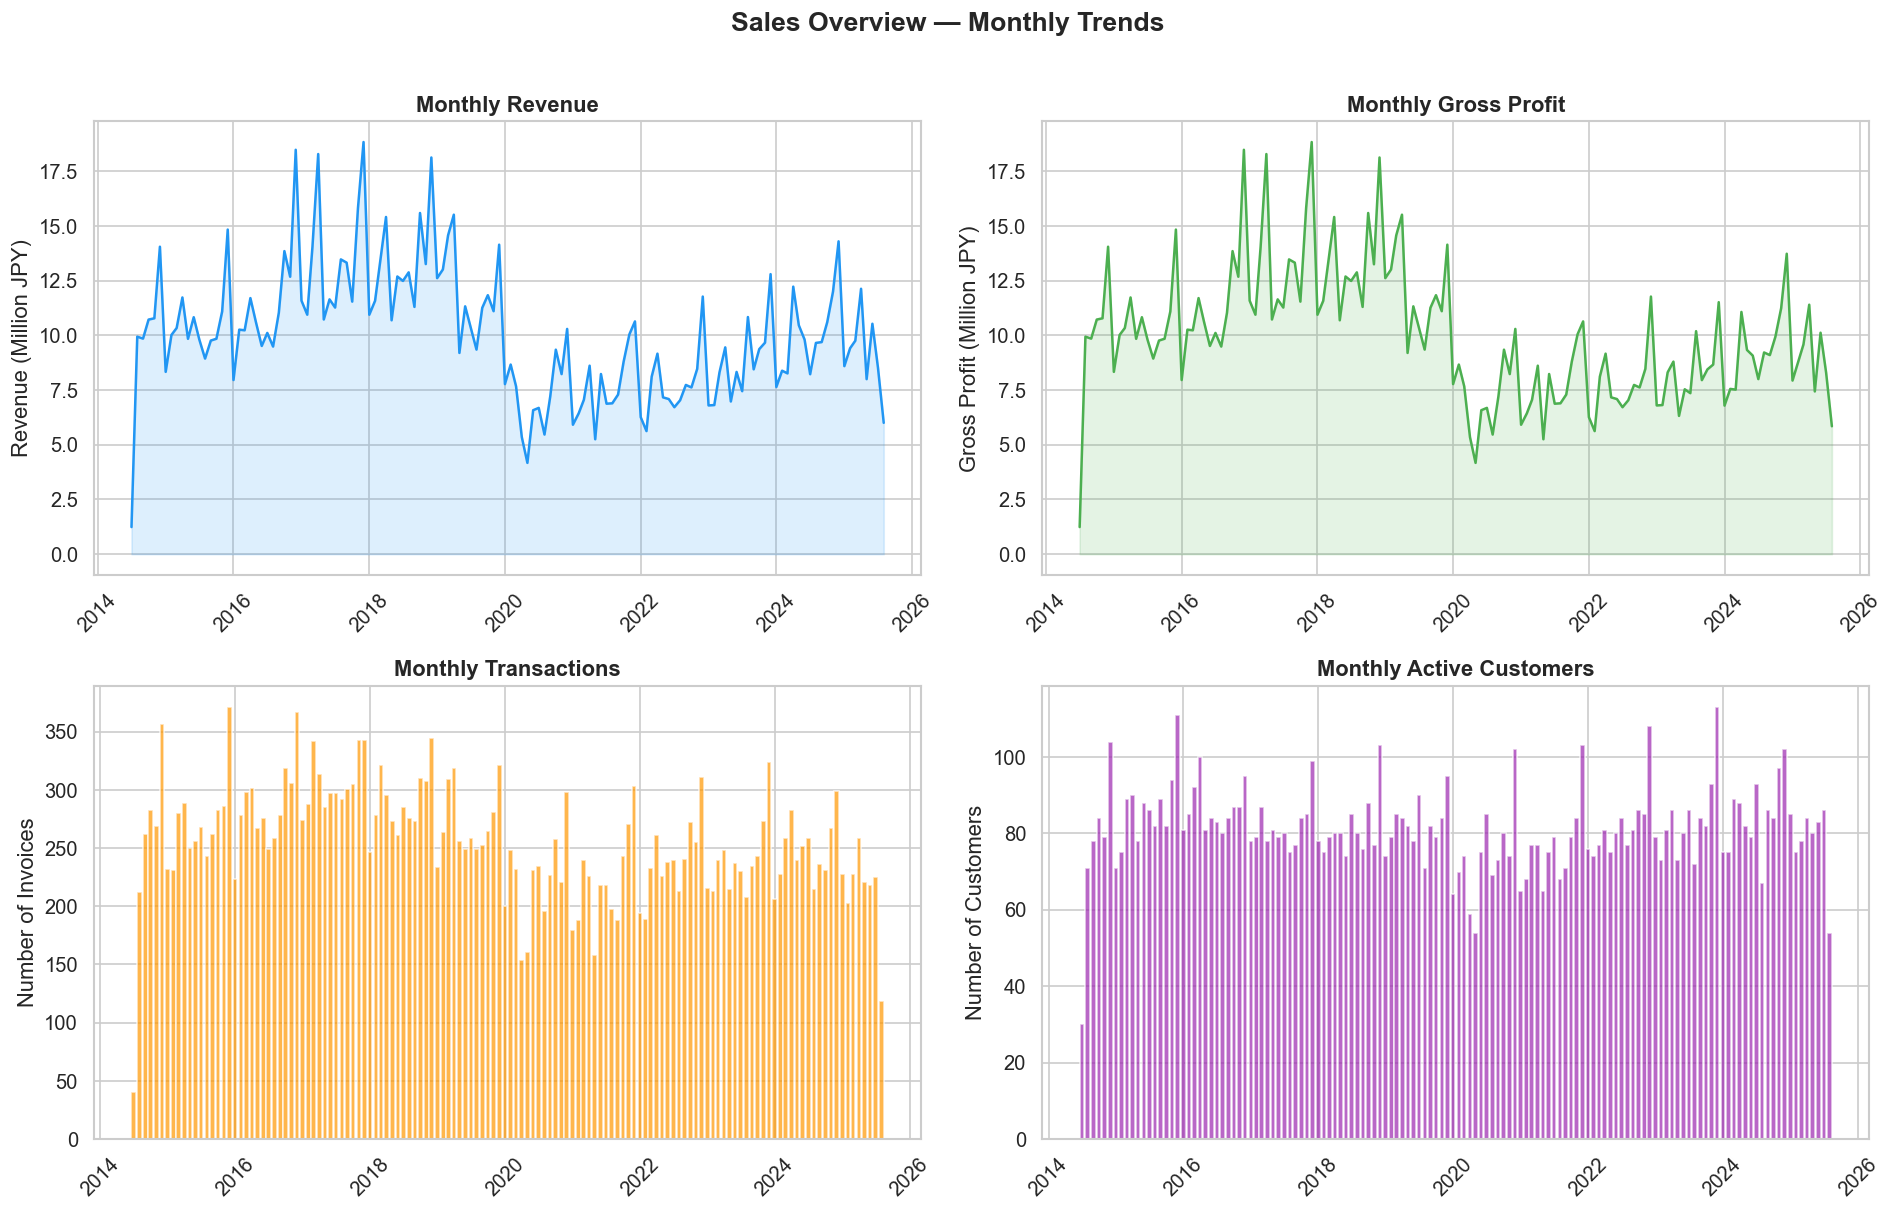

In [7]:
monthly_sales = df_clean.groupby("year_month").agg(
    total_revenue=("sales_amount", "sum"),
    total_profit=("gross_profit", "sum"),
    n_transactions=("invoice_no", "nunique"),
    n_customers=("customer_code", "nunique"),
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Revenue trend
axes[0, 0].plot(monthly_sales["year_month"], monthly_sales["total_revenue"] / 1e6,
                color="#2196F3", linewidth=1.5)
axes[0, 0].set_title("Monthly Revenue", fontweight="bold")
axes[0, 0].set_ylabel("Revenue (Million JPY)")
axes[0, 0].fill_between(monthly_sales["year_month"],
                         monthly_sales["total_revenue"] / 1e6, alpha=0.15, color="#2196F3")

# Gross profit trend
axes[0, 1].plot(monthly_sales["year_month"], monthly_sales["total_profit"] / 1e6,
                color="#4CAF50", linewidth=1.5)
axes[0, 1].set_title("Monthly Gross Profit", fontweight="bold")
axes[0, 1].set_ylabel("Gross Profit (Million JPY)")
axes[0, 1].fill_between(monthly_sales["year_month"],
                         monthly_sales["total_profit"] / 1e6, alpha=0.15, color="#4CAF50")

# Transaction count
axes[1, 0].bar(monthly_sales["year_month"], monthly_sales["n_transactions"],
               width=25, color="#FF9800", alpha=0.7)
axes[1, 0].set_title("Monthly Transactions", fontweight="bold")
axes[1, 0].set_ylabel("Number of Invoices")

# Active customers
axes[1, 1].bar(monthly_sales["year_month"], monthly_sales["n_customers"],
               width=25, color="#9C27B0", alpha=0.7)
axes[1, 1].set_title("Monthly Active Customers", fontweight="bold")
axes[1, 1].set_ylabel("Number of Customers")

for ax in axes.flat:
    ax.tick_params(axis="x", rotation=45)

plt.suptitle("Sales Overview — Monthly Trends", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "01_monthly_trends.png"), bbox_inches="tight")
plt.show()

## 1.4 Seasonality Analysis

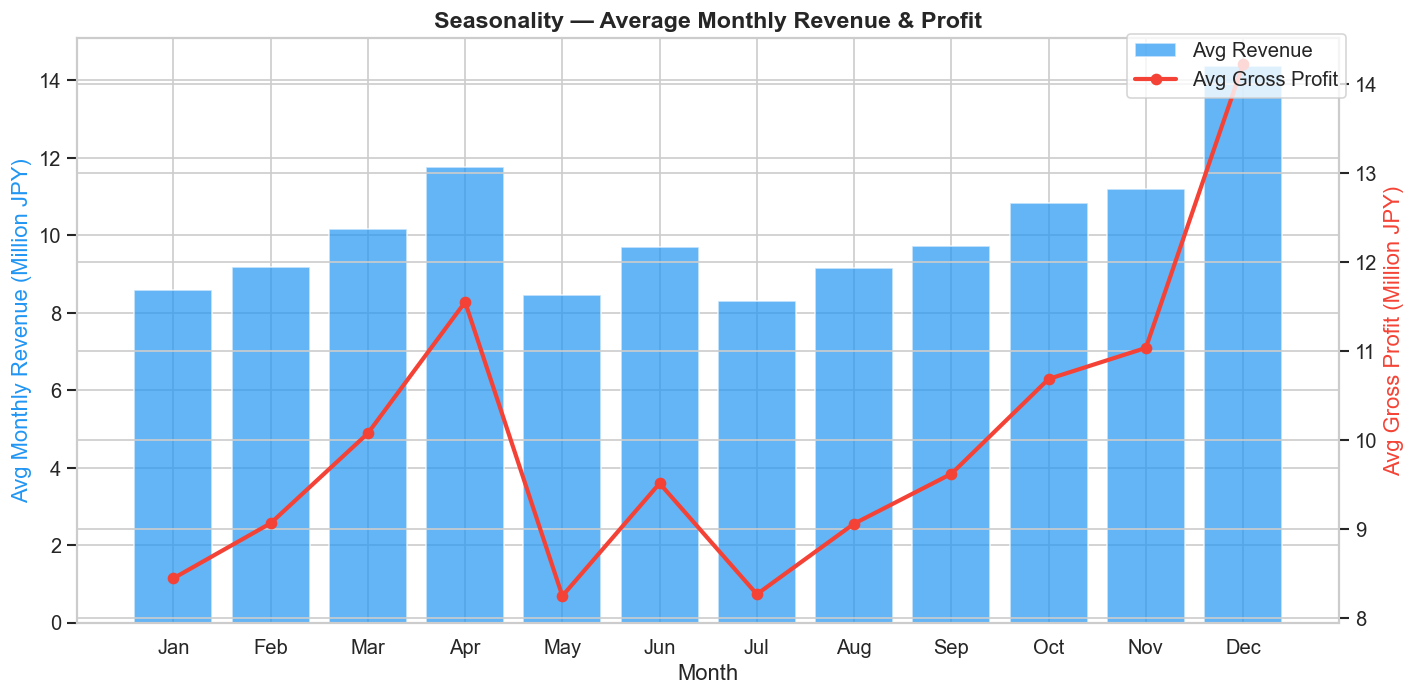

In [8]:
# Monthly averages across all years
seasonal = df_clean.groupby("month").agg(
    avg_revenue=("sales_amount", "sum"),
    avg_profit=("gross_profit", "sum"),
    avg_qty=("quantity", "sum"),
).reset_index()

# Normalize by number of years with data per month
years_per_month = df_clean.groupby("month")["year"].nunique().values
for col in ["avg_revenue", "avg_profit", "avg_qty"]:
    seasonal[col] = seasonal[col] / years_per_month

fig, ax1 = plt.subplots(figsize=(12, 6))
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

bars = ax1.bar(seasonal["month"], seasonal["avg_revenue"] / 1e6,
               color="#2196F3", alpha=0.7, label="Avg Revenue")
ax1.set_xlabel("Month")
ax1.set_ylabel("Avg Monthly Revenue (Million JPY)", color="#2196F3")
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(months)

ax2 = ax1.twinx()
ax2.plot(seasonal["month"], seasonal["avg_profit"] / 1e6,
         color="#F44336", marker="o", linewidth=2.5, label="Avg Gross Profit")
ax2.set_ylabel("Avg Gross Profit (Million JPY)", color="#F44336")

fig.legend(loc="upper right", bbox_to_anchor=(0.95, 0.95))
plt.title("Seasonality — Average Monthly Revenue & Profit", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "01_seasonality.png"), bbox_inches="tight")
plt.show()

## 1.5 Market Supply vs Company Sales

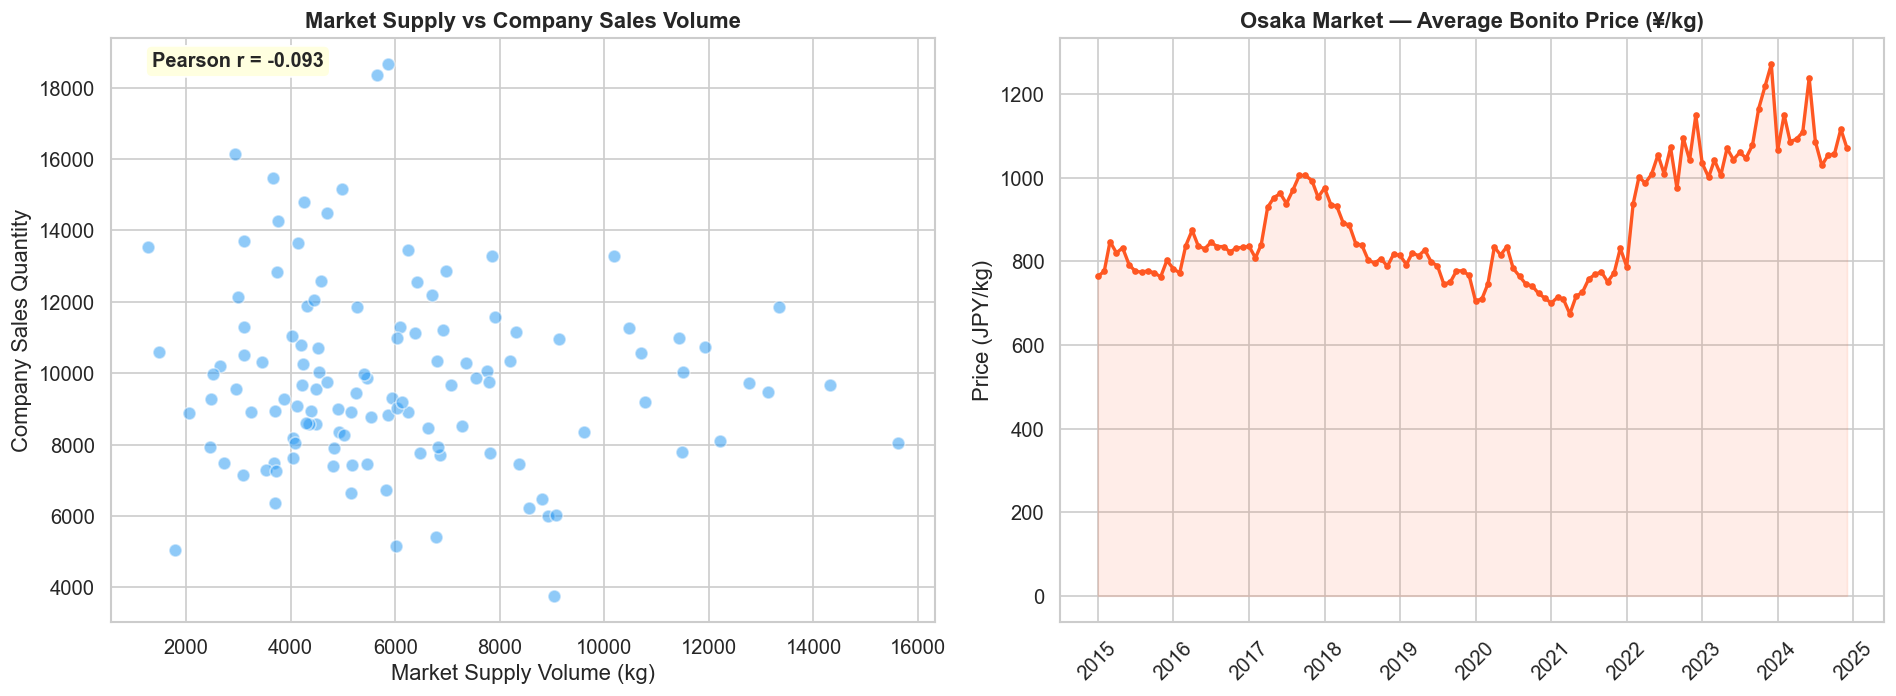

In [9]:
# Merge market data with company monthly sales
company_monthly = df_clean.groupby("year_month").agg(
    company_qty=("quantity", "sum"),
    company_revenue=("sales_amount", "sum"),
).reset_index()

merged = pd.merge(company_monthly, df_market[["date", "market_volume_kg", "market_avg_price"]],
                  left_on="year_month", right_on="date", how="inner")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Market volume vs company quantity
ax = axes[0]
ax.scatter(merged["market_volume_kg"], merged["company_qty"],
           alpha=0.5, c="#2196F3", edgecolors="white", s=60)
ax.set_xlabel("Market Supply Volume (kg)")
ax.set_ylabel("Company Sales Quantity")
ax.set_title("Market Supply vs Company Sales Volume", fontweight="bold")
# Add correlation
corr = merged["market_volume_kg"].corr(merged["company_qty"])
ax.annotate(f"Pearson r = {corr:.3f}", xy=(0.05, 0.95), xycoords="axes fraction",
            fontsize=12, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow"))

# Market price trend
ax = axes[1]
ax.plot(merged["year_month"], merged["market_avg_price"],
        color="#FF5722", linewidth=2, marker="o", markersize=3)
ax.set_title("Osaka Market — Average Bonito Price (¥/kg)", fontweight="bold")
ax.set_ylabel("Price (JPY/kg)")
ax.tick_params(axis="x", rotation=45)
ax.fill_between(merged["year_month"], merged["market_avg_price"], alpha=0.1, color="#FF5722")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "01_market_vs_company.png"), bbox_inches="tight")
plt.show()

## 1.6 Top Customers & Products

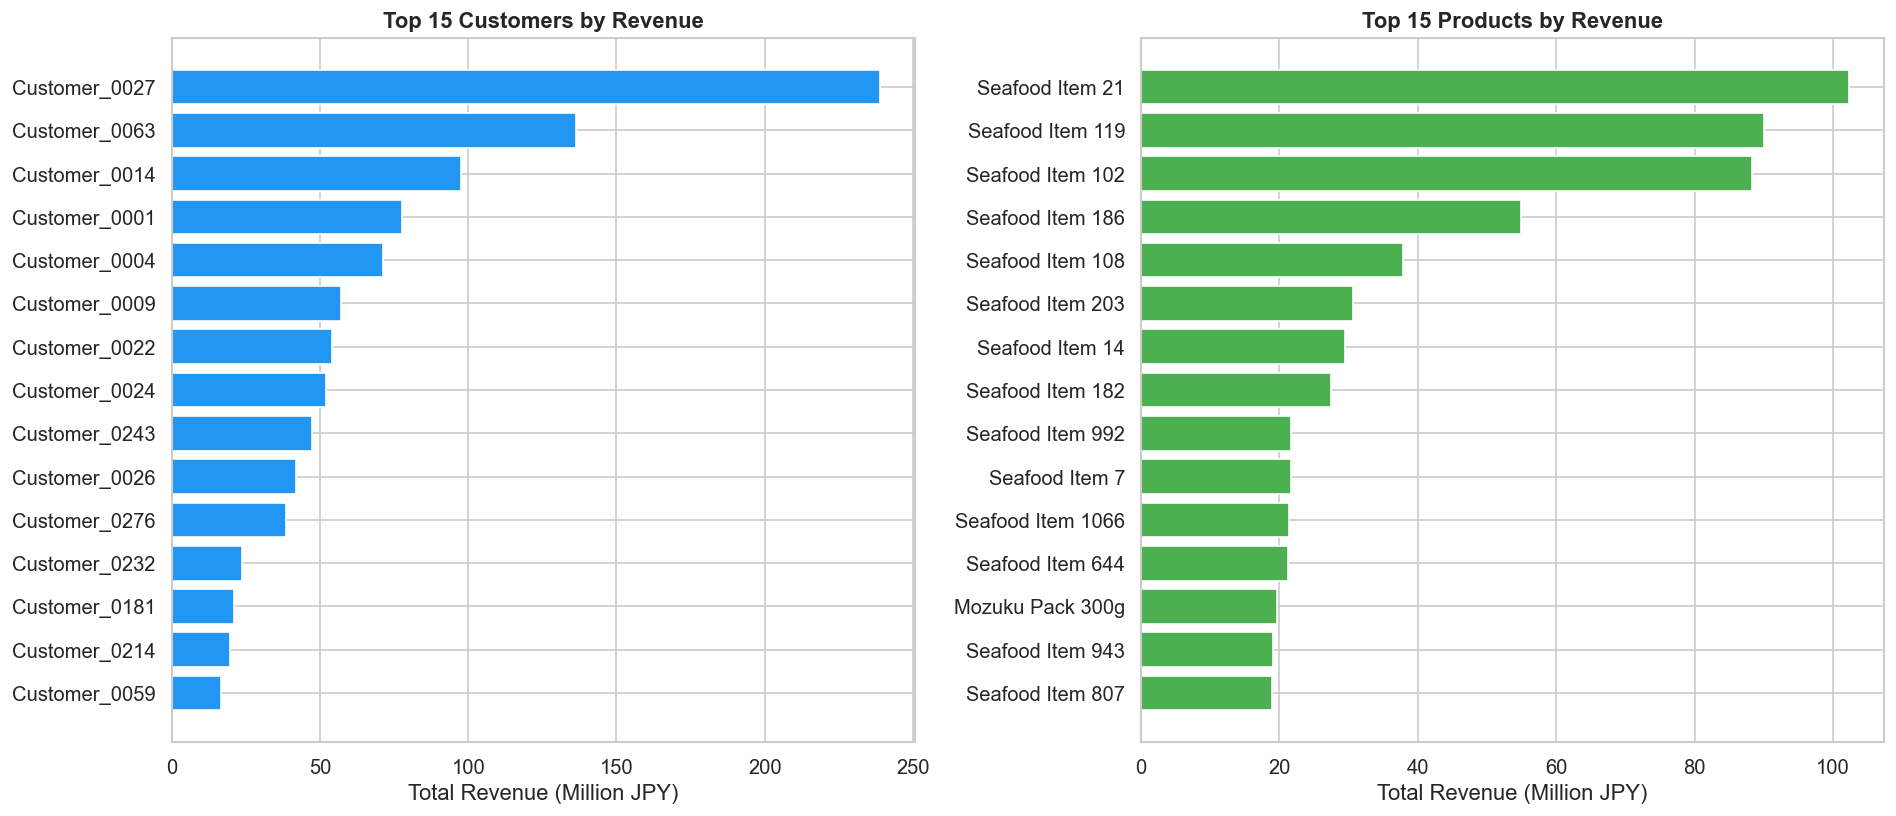

In [10]:
# Top 15 customers by revenue
top_customers = (df_clean.groupby(["customer_code", "customer_name"])["sales_amount"]
                 .sum().reset_index()
                 .sort_values("sales_amount", ascending=False).head(15))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(range(len(top_customers)), top_customers["sales_amount"] / 1e6, color="#2196F3")
axes[0].set_yticks(range(len(top_customers)))
axes[0].set_yticklabels(top_customers["customer_name"])
axes[0].set_xlabel("Total Revenue (Million JPY)")
axes[0].set_title("Top 15 Customers by Revenue", fontweight="bold")
axes[0].invert_yaxis()

# Top 15 products by revenue
top_products = (df_clean.groupby(["product_code", "product_name"])["sales_amount"]
                .sum().reset_index()
                .sort_values("sales_amount", ascending=False).head(15))

axes[1].barh(range(len(top_products)), top_products["sales_amount"] / 1e6, color="#4CAF50")
axes[1].set_yticks(range(len(top_products)))
axes[1].set_yticklabels(top_products["product_name"])
axes[1].set_xlabel("Total Revenue (Million JPY)")
axes[1].set_title("Top 15 Products by Revenue", fontweight="bold")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "01_top_customers_products.png"), bbox_inches="tight")
plt.show()

## 1.7 Product Category Distribution

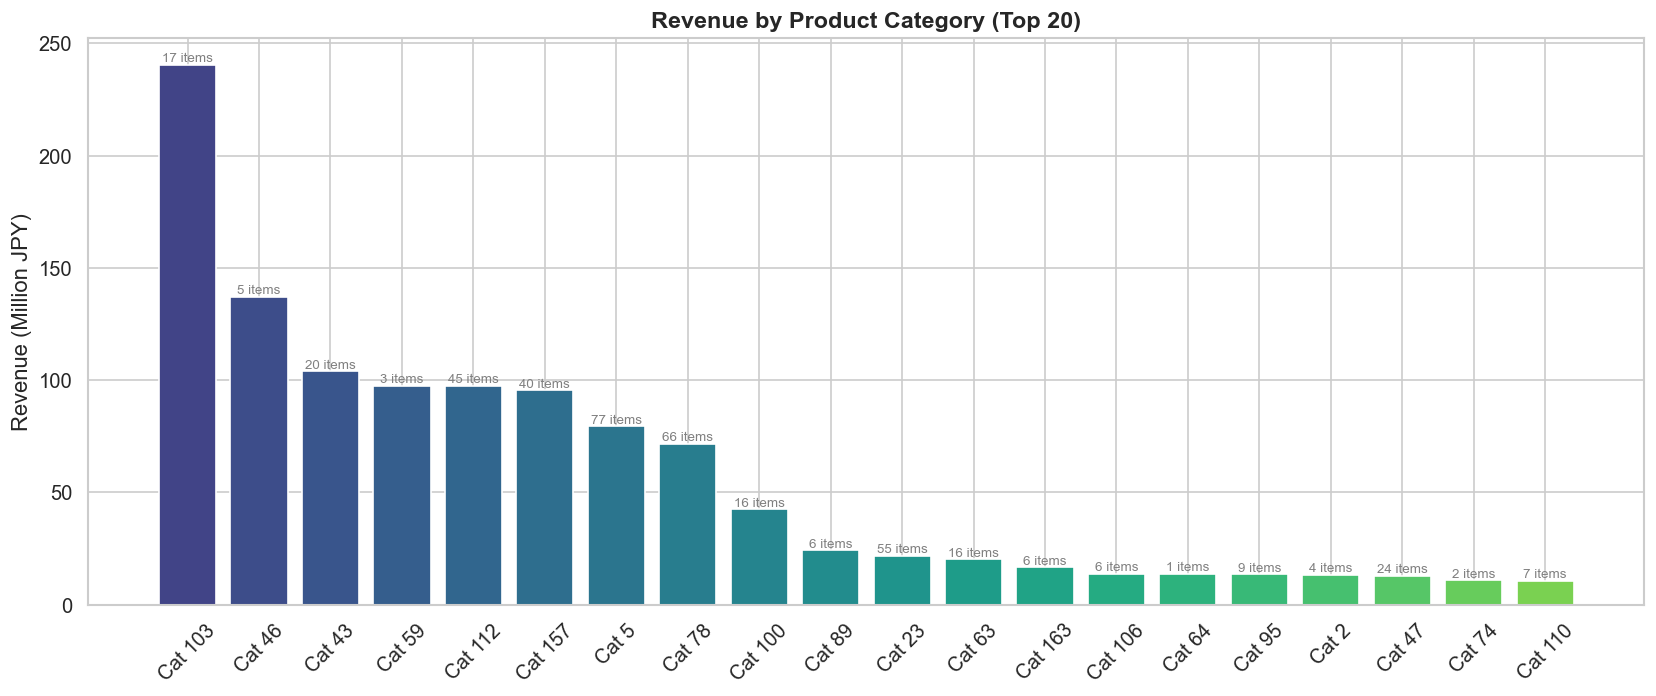

In [11]:
category_sales = (df_clean.dropna(subset=["product_category"])
                  .groupby("product_category")
                  .agg(revenue=("sales_amount", "sum"),
                       n_products=("product_code", "nunique"),
                       n_transactions=("invoice_no", "count"))
                  .sort_values("revenue", ascending=False)
                  .head(20).reset_index())

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(range(len(category_sales)),
              category_sales["revenue"] / 1e6,
              color=plt.cm.viridis(np.linspace(0.2, 0.8, len(category_sales))))
ax.set_xticks(range(len(category_sales)))
ax.set_xticklabels([f"Cat {int(c)}" for c in category_sales["product_category"]], rotation=45)
ax.set_ylabel("Revenue (Million JPY)")
ax.set_title("Revenue by Product Category (Top 20)", fontweight="bold", fontsize=14)

# Add product count labels
for i, (bar, n) in enumerate(zip(bars, category_sales["n_products"])):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{n} items", ha="center", va="bottom", fontsize=8, color="gray")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "01_category_distribution.png"), bbox_inches="tight")
plt.show()

## 1.8 Year-over-Year Comparison

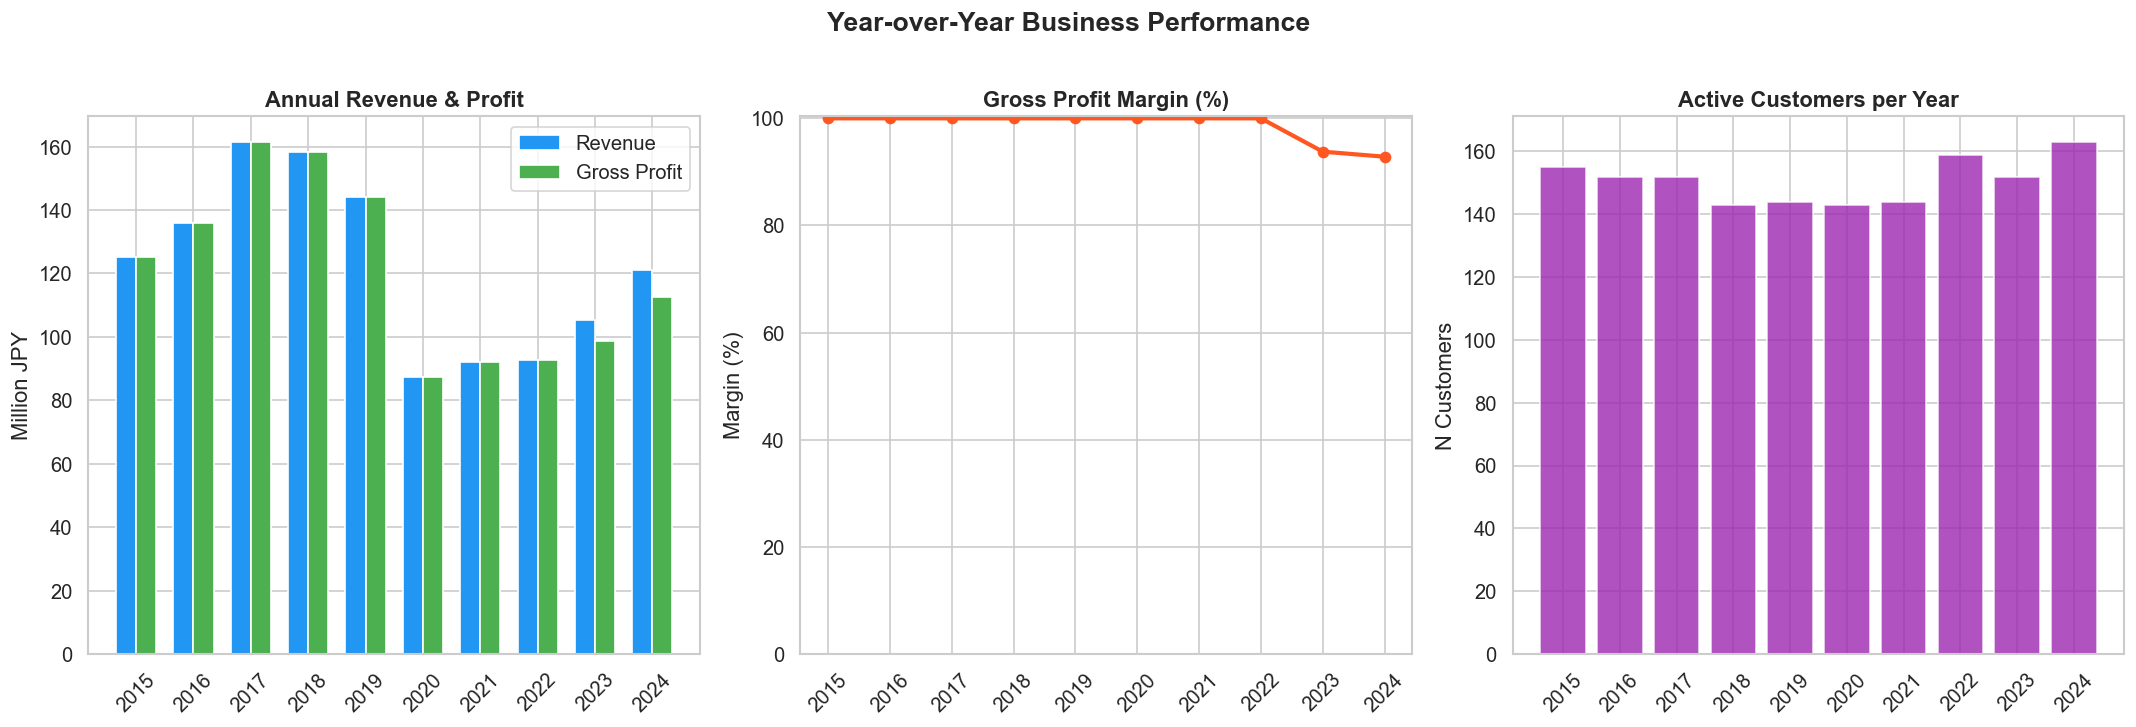

In [12]:
yearly = df_clean.groupby("year").agg(
    revenue=("sales_amount", "sum"),
    profit=("gross_profit", "sum"),
    customers=("customer_code", "nunique"),
    products=("product_code", "nunique"),
    transactions=("invoice_no", "nunique"),
).reset_index()

# Filter to complete years
yearly = yearly[(yearly["year"] >= 2015) & (yearly["year"] <= 2024)]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Revenue & Profit
years = yearly["year"]
x = np.arange(len(years))
w = 0.35
axes[0].bar(x - w/2, yearly["revenue"] / 1e6, w, label="Revenue", color="#2196F3")
axes[0].bar(x + w/2, yearly["profit"] / 1e6, w, label="Gross Profit", color="#4CAF50")
axes[0].set_xticks(x)
axes[0].set_xticklabels(years, rotation=45)
axes[0].set_ylabel("Million JPY")
axes[0].set_title("Annual Revenue & Profit", fontweight="bold")
axes[0].legend()

# Profit margin
yearly["margin"] = yearly["profit"] / yearly["revenue"] * 100
axes[1].plot(years, yearly["margin"], marker="o", linewidth=2.5, color="#FF5722")
axes[1].set_title("Gross Profit Margin (%)", fontweight="bold")
axes[1].set_ylabel("Margin (%)")
axes[1].set_xticks(years)
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_ylim(bottom=0)

# Customer count
axes[2].bar(years, yearly["customers"], color="#9C27B0", alpha=0.8)
axes[2].set_title("Active Customers per Year", fontweight="bold")
axes[2].set_ylabel("N Customers")
axes[2].set_xticks(years)
axes[2].tick_params(axis="x", rotation=45)

plt.suptitle("Year-over-Year Business Performance", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "01_yearly_comparison.png"), bbox_inches="tight")
plt.show()

## 1.9 Summary of Findings

| Metric | Value |
|---|---|
| Total transactions | ~80K records (2014-2025) |
| Active customers | 376 unique customers |
| Product SKUs | 1,794 unique products |
| Clear seasonality | Peak sales in summer months (bonito season) |
| Market correlation | Company sales loosely track market supply |
| Revenue concentration | Top 15 customers drive significant share |

In [13]:
print("=" * 60)
print("EDA Complete — Key Takeaways:")
print("=" * 60)
print(f"  • {len(df_clean):,} valid transactions analyzed")
print(f"  • {df_clean['customer_code'].nunique()} customers, {df_clean['product_code'].nunique()} products")
print(f"  • Date range: {df_clean['date'].min().date()} to {df_clean['date'].max().date()}")

# Revenue concentration
top10_rev = (df_clean.groupby("customer_code")["sales_amount"].sum()
             .sort_values(ascending=False).head(10).sum())
total_rev = df_clean["sales_amount"].sum()
print(f"  • Top 10 customers account for {top10_rev/total_rev*100:.1f}% of total revenue")
print(f"  • Figures saved to: {FIGURES_DIR}/")

EDA Complete — Key Takeaways:
  • 79,935 valid transactions analyzed
  • 303 customers, 1213 products
  • Date range: 2014-07-23 to 2025-08-20
  • Top 10 customers account for 67.6% of total revenue
  • Figures saved to: ..\results\figures/
